# 🗺️ Robot Pathing & Trajectory Overlay Analysis

สมุดบันทึกนี้ใช้สำหรับ **พล็อตเปรียบเทียบเส้นทางในแผนที่ (Planned Path) กับเส้นทางการเดินจริงของหุ่นยนต์ (Actual Trajectory)** บนตาราง Grid Map (60x60 cm) โดย:
1. **โหลดแผนที่และเส้นทางที่วางแผนไว้**: จาก `data/robot_map_plan.json` (ที่ Export มาจาก `map.py` / `map_planner.py`)
2. **โหลดข้อมูล Telemetry การเดินจริง**: จาก `telemetry_logs/` (บันทึกอัตโนมัติจากการรันหุ่นยนต์)
3. **แปลงพิกัดและพล็อตเส้นทางทับบนแผนที่**: แสดงกำแพง, จุด Start, จุด Goal, เส้นทางวางแผน (A*), และเส้นทางเดินจริงของหุ่นยนต์
4. **วิเคราะห์ความแม่นยำ (Path Accuracy & Metrics)**: คำนวณระยะทางรวม, ค่าความคลาดเคลื่อนเบี่ยงเบน (Cross-Track / Lateral Error), และโปรไฟล์เซนเซอร์

In [1]:
import os
import json
import math
import glob
from pathlib import Path
from typing import Dict, Any, List, Tuple, Optional

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ตั้งค่าฟอนต์และการแสดงผลกราฟ
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'sans-serif']
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.2

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. โหลดข้อมูลแผนที่ (Load Map Plan from `map.py` / `robot_map_plan.json`)

In [2]:
def load_map_plan(json_path: str = "../data/robot_map_plan.json") -> Dict[str, Any]:
    """โหลดข้อมูล Grid, Start, Goal, Walls และ Planned Path จากไฟล์ JSON"""
    candidate_paths = [
        Path(json_path),
        Path("data/robot_map_plan.json"),
        Path("../data/robot_map_plan.json"),
        Path(__file__).resolve().parent.parent / "data" / "robot_map_plan.json" if "__file__" in globals() else None
    ]
    
    target_path = None
    for p in candidate_paths:
        if p and p.exists():
            target_path = p
            break
            
    if not target_path:
        raise FileNotFoundError(f"Cannot find robot_map_plan.json in data/ or ../data/")
            
    with open(target_path, "r", encoding="utf-8") as f:
        map_data = json.load(f)
        
    grid_info = map_data.get("grid_info", {"rows": 6, "cols": 5})
    rows = grid_info.get("rows", 6)
    cols = grid_info.get("cols", 5)
    start = map_data.get("start", [0, 5])
    goal = map_data.get("goal", [3, 1])
    walls = map_data.get("walls", [])
    path_cells = map_data.get("path", [])
    commands = map_data.get("commands", [])
    
    print(f"Loaded Map: {cols}x{rows} Grid | Start: {start} | Goal: {goal}")
    print(f"Planned Path: {len(path_cells)} Waypoints | Commands: {len(commands)} Steps")
    return map_data

# โหลดแผนที่
map_data = load_map_plan()

Loaded Map: 5x6 Grid | Start: [0, 5] | Goal: [3, 1]
Planned Path: 12 Waypoints | Commands: 11 Steps


## 2. ค้นหาและโหลด Telemetry Log การเดินจริง (Find & Load Telemetry Log)

In [3]:
def find_available_runs(base_dir: str = "../telemetry_logs") -> List[Tuple[Path, List[Path]]]:
    """ค้นหาเฉพาะโฟลเดอร์ run ที่มีไฟล์ telemetry .json อยู่จริง"""
    p = Path(base_dir)
    if not p.exists():
        p = Path("telemetry_logs")
    if not p.exists():
        return []
        
    valid_runs = []
    for d in p.iterdir():
        if d.is_dir() and d.name.startswith("run"):
            json_files = sorted(list(d.glob("*.json")))
            if json_files:  # เฉพาะโฟลเดอร์ที่มีไฟล์ JSON
                valid_runs.append((d, json_files))
                
    valid_runs.sort(key=lambda x: int(x[0].name.replace("run", "")) if x[0].name.replace("run", "").isdigit() else 0)
    return valid_runs

def load_latest_telemetry(run_dir: Optional[str] = None) -> Tuple[Dict[str, Any], Path]:
    """โหลดไฟล์ JSON ล่าสุดจาก run ที่มีข้อมูล"""
    if run_dir is not None:
        target_dir = Path(run_dir)
        json_files = sorted(list(target_dir.glob("*.json")))
        if not json_files:
            raise FileNotFoundError(f"No JSON file found in {target_dir}")
        target_file = json_files[-1]
    else:
        runs = find_available_runs()
        if not runs:
            raise FileNotFoundError("No telemetry runs with JSON data found in telemetry_logs/! Please run a simulation or physical test first.")
        target_dir, json_files = runs[-1]  # เลือก run ล่าสุดที่มีข้อมูล
        target_file = json_files[-1]
        
    with open(target_file, "r", encoding="utf-8") as f:
        telemetry_data = json.load(f)
        
    print(f"Loaded Telemetry from: {target_file.parent.name}/{target_file.name}")
    print(f"Total Samples: {len(telemetry_data.get('records', []))} records")
    return telemetry_data, target_file

# แสดง Run ที่มีข้อมูลทั้งหมด
available_runs = find_available_runs()
print("Available Runs with data:", [r[0].name for r in available_runs])

# โหลด Run ล่าสุด
telemetry_data, telemetry_file_path = load_latest_telemetry()

Available Runs with data: ['run1', 'run2', 'run3', 'run4', 'run5', 'run6']
Loaded Telemetry from: run6/run6_20260827_095257.json
Total Samples: 1510 records


## 3. แปลงพิกัดการเดินของหุ่นยนต์ (Transform Robot Local Frame $\rightarrow$ Grid Map Frame)

* **ขนาด Grid ช่องละ**: $0.60\text{ m} \times 0.60\text{ m}$
* **จุดเริ่มต้น**: $Start = (col_{start}, row_{start}) = (0, 5)$
* **ทิศทางเริ่มต้นของหุ่นยนต์**: หันหน้าไปทาง **North (ขึ้น)**
  * เมื่อหุ่นยนต์เดินหน้า $+pos\_x$ $\rightarrow$ ในแผนที่คือการเคลื่อนที่ขึ้น (ลดค่า $row$)
  * เมื่อหุ่นยนต์ขยับซ้าย/ขวา $+pos\_y$ $\rightarrow$ ในแผนที่คือการเคลื่อนที่ไปทางขวา (เพิ่มค่า $col$)
* **สมการแปลงพิกัดกึ่งกลางช่อง Grid**:
  $$X_{grid}(t) = col_{start} + 0.5 + \frac{pos\_y(t)}{0.60}$$
  $$Y_{grid}(t) = row_{start} + 0.5 - \frac{pos\_x(t)}{0.60}$$

In [4]:
CELL_SIZE_METERS = 0.60  # 60 cm ต่อ 1 Grid

def extract_robot_trajectory(telemetry: Dict[str, Any], start_cell: List[int]) -> Dict[str, np.ndarray]:
    """ดึงข้อมูลการเคลื่อนที่และแปลงเป็นพิกัด Grid Map และ Metric Coordinates"""
    records = telemetry.get("records", [])
    if not records:
        return {}
        
    start_col, start_row = start_cell[0], start_cell[1]
    
    t_elapsed = np.array([r.get("elapsed_sec", 0.0) for r in records])
    pos_x = np.array([r.get("pos_x", 0.0) for r in records])      # Local Forward (m)
    pos_y = np.array([r.get("pos_y", 0.0) for r in records])      # Local Lateral (m)
    yaw = np.array([r.get("yaw", 0.0) for r in records])          # Heading (deg)
    
    sl_mm = np.array([r.get("sharp_left_mm", np.nan) for r in records])
    sr_mm = np.array([r.get("sharp_right_mm", np.nan) for r in records])
    tof_mm = np.array([r.get("tof_filtered_mm", np.nan) for r in records])
    
    # แปลงเป็นพิกัด Grid Units (0..COLS, 0..ROWS โดย (0,0) อยู่มุมบนซ้ายตามแบบจำลองแผนที่)
    grid_x = start_col + 0.5 + (pos_y / CELL_SIZE_METERS)
    grid_y = start_row + 0.5 - (pos_x / CELL_SIZE_METERS)
    
    # แปลงเป็นหน่วยเมตรในพิกัดแผนที่ (Meters from top-left origin)
    meters_x = grid_x * CELL_SIZE_METERS
    meters_y = grid_y * CELL_SIZE_METERS
    
    return {
        "t": t_elapsed,
        "pos_x": pos_x,
        "pos_y": pos_y,
        "yaw": yaw,
        "grid_x": grid_x,
        "grid_y": grid_y,
        "meters_x": meters_x,
        "meters_y": meters_y,
        "sharp_left_mm": sl_mm,
        "sharp_right_mm": sr_mm,
        "tof_mm": tof_mm,
    }

start_point = map_data.get("start", [0, 5])
traj = extract_robot_trajectory(telemetry_data, start_point)
print(f"Extracted {len(traj['t'])} trajectory points. Duration: {traj['t'][-1] if len(traj['t']) > 0 else 0:.2f} s")

Extracted 1510 trajectory points. Duration: 91.43 s


## 4. พล็อตเส้นทางจริงทับบนแผนที่ (Overlay Trajectory on Grid Map)

Saved trajectory map plot to: pathing_overlay_plot.png


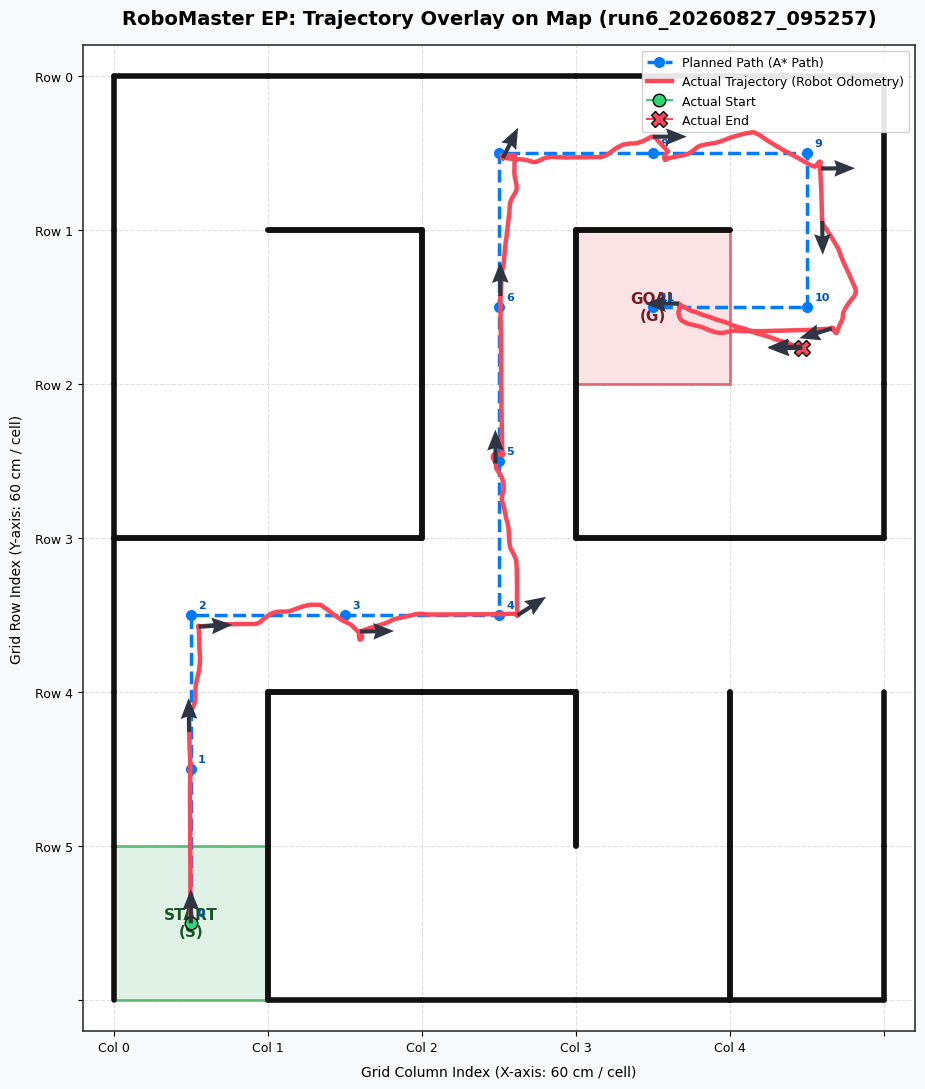

In [5]:
def plot_map_with_trajectory(
    map_data: Dict[str, Any],
    traj: Dict[str, np.ndarray],
    title: str = "RoboMaster EP: Planned vs Actual Path on Grid Map",
    save_path: Optional[str] = None,
):
    """วาดแผนที่ กำแพง ทางเดินที่วางแผนไว้ และพล็อตเส้นทางเดินจริงทับลงไป"""
    grid_info = map_data.get("grid_info", {"rows": 6, "cols": 5})
    rows = grid_info.get("rows", 6)
    cols = grid_info.get("cols", 5)
    start = map_data.get("start", [0, 5])
    goal = map_data.get("goal", [3, 1])
    path_cells = map_data.get("path", [])
    walls = map_data.get("walls", [])
    
    fig, ax = plt.subplots(figsize=(10, 11), facecolor="#f8f9fa")
    ax.set_facecolor("#ffffff")
    
    # 1. วาดเส้น Grid ย่อย
    for r in range(rows + 1):
        ax.axhline(r, color="#e0e0e0", linestyle="--", linewidth=0.8, zorder=1)
    for c in range(cols + 1):
        ax.axvline(c, color="#e0e0e0", linestyle="--", linewidth=0.8, zorder=1)
        
    # 2. ไฮไลต์ช่อง Start และ Goal
    start_patch = patches.Rectangle((start[0], start[1]), 1, 1, facecolor="#d4edda", edgecolor="#28a745", linewidth=2, alpha=0.7, zorder=2)
    ax.add_patch(start_patch)
    ax.text(start[0] + 0.5, start[1] + 0.5, "START\n(S)", color="#155724", weight="bold", fontsize=11, ha="center", va="center", zorder=3)
    
    goal_patch = patches.Rectangle((goal[0], goal[1]), 1, 1, facecolor="#f8d7da", edgecolor="#dc3545", linewidth=2, alpha=0.7, zorder=2)
    ax.add_patch(goal_patch)
    ax.text(goal[0] + 0.5, goal[1] + 0.5, "GOAL\n(G)", color="#721c24", weight="bold", fontsize=11, ha="center", va="center", zorder=3)
    
    # 3. วาดกำแพง (Walls) จาก Map Data
    wall_color = "#111111"
    wall_thickness = 4.0
    for w in walls:
        c, r = w["pos"][0], w["pos"][1]
        wall_dict = w.get("walls", {})
        if wall_dict.get("top", False):
            ax.plot([c, c + 1], [r, r], color=wall_color, linewidth=wall_thickness, solid_capstyle="round", zorder=5)
        if wall_dict.get("bottom", False):
            ax.plot([c, c + 1], [r + 1, r + 1], color=wall_color, linewidth=wall_thickness, solid_capstyle="round", zorder=5)
        if wall_dict.get("left", False):
            ax.plot([c, c], [r, r + 1], color=wall_color, linewidth=wall_thickness, solid_capstyle="round", zorder=5)
        if wall_dict.get("right", False):
            ax.plot([c + 1, c + 1], [r, r + 1], color=wall_color, linewidth=wall_thickness, solid_capstyle="round", zorder=5)
            
    # 4. วาด Planned Path (เส้นประสีน้ำเงิน A* Path)
    if path_cells:
        px = [p[0] + 0.5 for p in path_cells]
        py = [p[1] + 0.5 for p in path_cells]
        ax.plot(px, py, "o--", color="#007bff", linewidth=2.5, markersize=7, label="Planned Path (A* Path)", zorder=4)
        for idx, (cx, cy) in enumerate(zip(px, py)):
            ax.annotate(str(idx), (cx, cy), textcoords="offset points", xytext=(5, 5), fontsize=8, color="#0056b3", weight="bold", zorder=6)
            
    # 5. วาด Actual Robot Trajectory (เส้นทึบสีแดง)
    if traj and len(traj.get("grid_x", [])) > 0:
        gx = traj["grid_x"]
        gy = traj["grid_y"]
        
        # เส้นทางเดินจริง
        ax.plot(gx, gy, "-", color="#ff4757", linewidth=3.2, label="Actual Trajectory (Robot Odometry)", zorder=7)
        
        # Marker จุดเริ่มต้นจริง และจุดสิ้นสุดจริง
        ax.plot(gx[0], gy[0], marker="o", markersize=9, color="#2ed573", markeredgecolor="black", label="Actual Start", zorder=8)
        ax.plot(gx[-1], gy[-1], marker="X", markersize=11, color="#ff4757", markeredgecolor="black", label="Actual End", zorder=8)
        
        # วาดลูกศรบอกทิศทาง (Heading) ของหุ่นยนต์เป็นระยะๆ
        arrow_step = max(1, len(gx) // 15)
        for i in range(0, len(gx), arrow_step):
            yaw_deg = traj["yaw"][i]
            yaw_rad = math.radians(yaw_deg)
            u = 0.22 * math.sin(yaw_rad)   # dx ในพิกัดแผนที่
            v = -0.22 * math.cos(yaw_rad)  # dy ในพิกัดแผนที่ (ลดลงคือขึ้นบน)
            ax.quiver(gx[i], gy[i], u, v, angles='xy', scale_units='xy', scale=1.0, color="#2f3542", width=0.005, headwidth=4, zorder=8)
            
    # ตั้งค่าแกนแผนที่ (Invert Y-axis ให้ row 0 อยู่ด้านบนสุดเหมือนใน map.py)
    ax.set_xlim(-0.2, cols + 0.2)
    ax.set_ylim(rows + 0.2, -0.2)  # Inverted Y: 0 อยู่บน, rows อยู่ล่าง
    ax.set_aspect("equal")
    
    # Labels & Ticks
    ax.set_xticks(range(cols + 1))
    ax.set_yticks(range(rows + 1))
    ax.set_xticklabels([f"Col {c}" if c < cols else "" for c in range(cols + 1)], fontsize=9)
    ax.set_yticklabels([f"Row {r}" if r < rows else "" for r in range(rows + 1)], fontsize=9)
    
    ax.set_title(title, fontsize=14, weight="bold", pad=15)
    ax.set_xlabel("Grid Column Index (X-axis: 60 cm / cell)", fontsize=10, labelpad=8)
    ax.set_ylabel("Grid Row Index (Y-axis: 60 cm / cell)", fontsize=10, labelpad=8)
    ax.grid(False)
    ax.legend(loc="upper right", framealpha=0.9, fontsize=9)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved trajectory map plot to: {save_path}")
    plt.show()

# รันการพล็อต
plot_map_with_trajectory(
    map_data=map_data, 
    traj=traj, 
    title=f"RoboMaster EP: Trajectory Overlay on Map ({telemetry_file_path.stem})",
    save_path="pathing_overlay_plot.png"
)

## 5. การวิเคราะห์ความคลาดเคลื่อนและสถิติการเดิน (Quantitative Path Metrics)

In [6]:
def calculate_path_metrics(map_data: Dict[str, Any], traj: Dict[str, np.ndarray]) -> Dict[str, Any]:
    """คำนวณระยะทางรวม ความเร็ว และความคลาดเคลื่อนเบี่ยงเบนจากเส้นทาง"""
    path_cells = map_data.get("path", [])
    if not path_cells or not traj or len(traj.get("meters_x", [])) < 2:
        return {}
        
    # 1. Planned Distance
    planned_dist_m = (len(path_cells) - 1) * CELL_SIZE_METERS
    
    # 2. Actual Distance
    mx, my = traj["meters_x"], traj["meters_y"]
    dx = np.diff(mx)
    dy = np.diff(my)
    actual_dist_m = float(np.sum(np.sqrt(dx**2 + dy**2)))
    
    # 3. Time & Speed
    duration_s = float(traj["t"][-1] - traj["t"][0]) if len(traj["t"]) > 1 else 0.0
    avg_speed_mps = (actual_dist_m / duration_s) if duration_s > 0 else 0.0
    
    # 4. Waypoint Cross-Track Deviation
    planned_pts = np.array([[p[0] + 0.5, p[1] + 0.5] for p in path_cells]) * CELL_SIZE_METERS
    actual_pts = np.column_stack([mx, my])
    
    min_deviations = []
    for pt in actual_pts:
        dists = np.linalg.norm(planned_pts - pt, axis=1)
        min_deviations.append(np.min(dists))
        
    min_dev_arr = np.array(min_deviations) * 1000.0  # แปลงเป็น mm
    
    metrics = {
        "planned_distance_m": planned_dist_m,
        "actual_distance_m": actual_dist_m,
        "duration_sec": duration_s,
        "avg_speed_mps": avg_speed_mps,
        "mean_deviation_mm": float(np.mean(min_dev_arr)),
        "max_deviation_mm": float(np.max(min_dev_arr)),
        "std_deviation_mm": float(np.std(min_dev_arr)),
        "final_goal_error_mm": float(np.linalg.norm(actual_pts[-1] - planned_pts[-1]) * 1000.0),
    }
    
    print("=" * 55)
    print("📊 PATH ACCURACY & TRAJECTORY PERFORMANCE SUMMARY")
    print("=" * 55)
    print(f"Planned Distance (A*)   : {metrics['planned_distance_m']:.3f} m ({len(path_cells)-1} grid cells)")
    print(f"Actual Traveled Distance: {metrics['actual_distance_m']:.3f} m")
    print(f"Execution Duration      : {metrics['duration_sec']:.2f} s")
    print(f"Average Speed           : {metrics['avg_speed_mps']:.3f} m/s")
    print(f"Mean Path Deviation     : {metrics['mean_deviation_mm']:.2f} mm")
    print(f"Max Path Deviation      : {metrics['max_deviation_mm']:.2f} mm")
    print(f"Std Path Deviation      : {metrics['std_deviation_mm']:.2f} mm")
    print(f"Final Goal Position Err : {metrics['final_goal_error_mm']:.2f} mm")
    print("=" * 55)
    
    return metrics

metrics = calculate_path_metrics(map_data, traj)

📊 PATH ACCURACY & TRAJECTORY PERFORMANCE SUMMARY
Planned Distance (A*)   : 6.600 m (11 grid cells)
Actual Traveled Distance: 8.045 m
Execution Duration      : 75.67 s
Average Speed           : 0.106 m/s
Mean Path Deviation     : 118.67 mm
Max Path Deviation      : 310.54 mm
Std Path Deviation      : 73.19 mm
Final Goal Position Err : 601.88 mm


## 6. กราฟโปรไฟล์เซนเซอร์ขณะเดิน (Sensor & Heading Profiles vs Time)

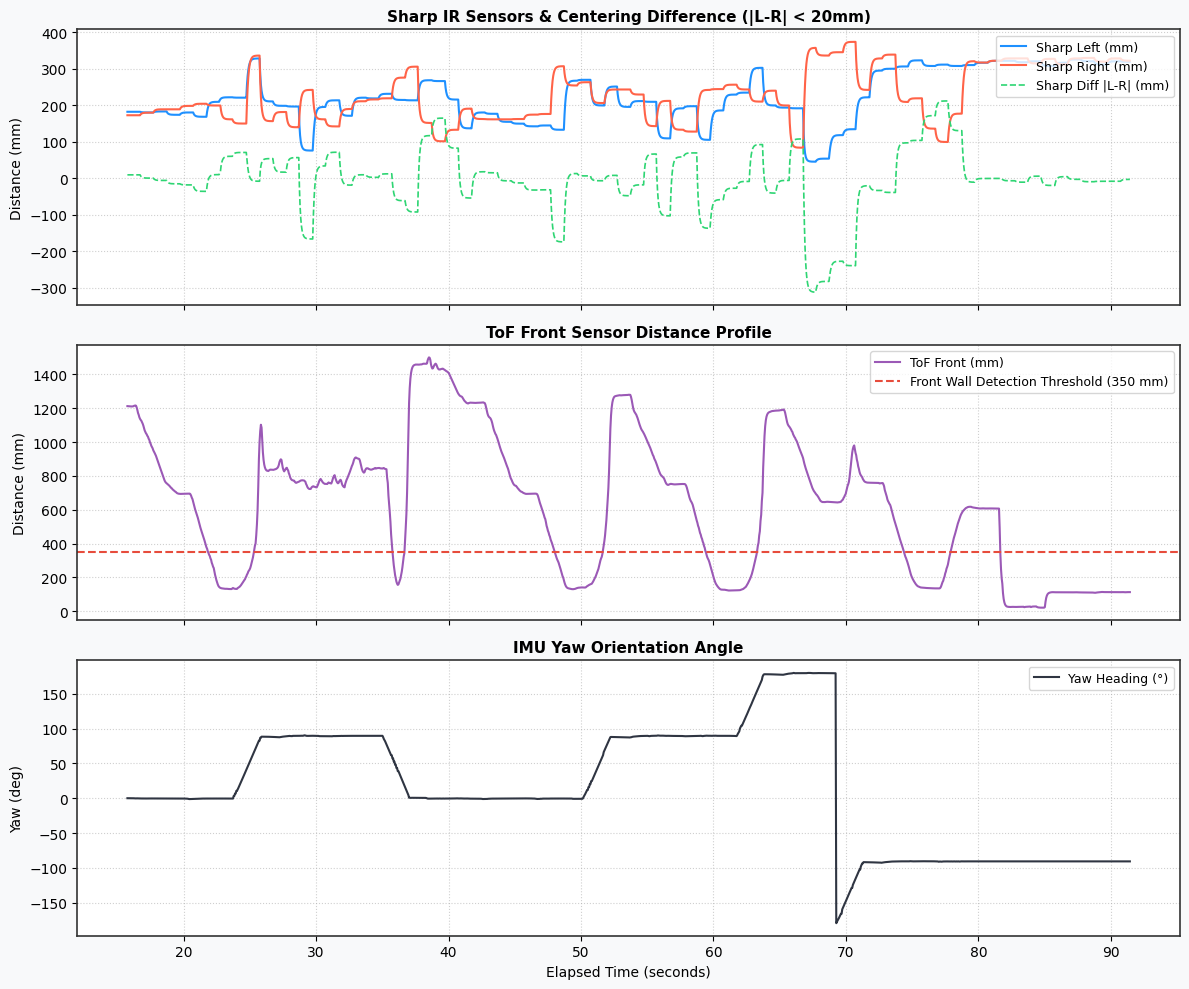

In [7]:
if traj and len(traj.get("t", [])) > 0:
    t = traj["t"]
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True, facecolor="#f8f9fa")
    
    # 1. Sharp Left / Right & Difference
    ax1.plot(t, traj["sharp_left_mm"], label="Sharp Left (mm)", color="#1e90ff", linewidth=1.5)
    ax1.plot(t, traj["sharp_right_mm"], label="Sharp Right (mm)", color="#ff6348", linewidth=1.5)
    diff = traj["sharp_left_mm"] - traj["sharp_right_mm"]
    ax1.plot(t, diff, label="Sharp Diff |L-R| (mm)", color="#2ed573", linestyle="--", linewidth=1.2)
    ax1.set_ylabel("Distance (mm)", fontsize=10)
    ax1.set_title("Sharp IR Sensors & Centering Difference (|L-R| < 20mm)", fontsize=11, weight="bold")
    ax1.grid(True, linestyle=":", alpha=0.6)
    ax1.legend(loc="upper right", fontsize=9)
    
    # 2. ToF Front Distance
    ax2.plot(t, traj["tof_mm"], label="ToF Front (mm)", color="#9b59b6", linewidth=1.5)
    ax2.axhline(350, color="#e74c3c", linestyle="--", label="Front Wall Detection Threshold (350 mm)")
    ax2.set_ylabel("Distance (mm)", fontsize=10)
    ax2.set_title("ToF Front Sensor Distance Profile", fontsize=11, weight="bold")
    ax2.grid(True, linestyle=":", alpha=0.6)
    ax2.legend(loc="upper right", fontsize=9)
    
    # 3. IMU Yaw & Odometry Position
    ax3.plot(t, traj["yaw"], label="Yaw Heading (°)", color="#2f3542", linewidth=1.5)
    ax3.set_ylabel("Yaw (deg)", fontsize=10)
    ax3.set_xlabel("Elapsed Time (seconds)", fontsize=10)
    ax3.set_title("IMU Yaw Orientation Angle", fontsize=11, weight="bold")
    ax3.grid(True, linestyle=":", alpha=0.6)
    ax3.legend(loc="upper right", fontsize=9)
    
    plt.tight_layout()
    plt.show()